# Submission Visualization

Five views of the final ensemble submission (`submission_ensemble.csv`):

1. **DE value distribution** — overall histogram of all predicted values
2. **Clustermap** — 120 perturbations × 5,127 genes heatmap with clustering
3. **Response magnitude** — which knockdowns cause the strongest transcriptional effect
4. **Top responding genes** — per-perturbation bar charts for a few examples
5. **UMAP** — perturbation DE vectors in 2D, overlaid with training ground truth

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Paths
ROOT = Path('..').resolve()
SUB_DIR  = ROOT / 'outputs' / 'submissions'
FIG_DIR  = ROOT / 'outputs' / 'figures'
DATA_DIR = ROOT / 'data' / 'echoes-of-silenced-genes'

FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = sns.color_palette('tab10')
print('Ready.')

Ready.


In [2]:
# ── Load submission ─────────────────────────────────────────────────────────
sub = pd.read_csv(SUB_DIR / 'submission_gnn_v3_local.csv', index_col=0)
print(f'Submission shape: {sub.shape}')  # (120, 5127)

# ── Load training ground truth (for overlay in UMAP) ───────────────────────
gt_path = DATA_DIR / 'training_data_ground_truth_table.csv'
has_gt  = gt_path.exists()

if has_gt:
    gt_raw   = pd.read_csv(gt_path, index_col=0)
    de_cols  = [c for c in gt_raw.columns if not c.startswith('w_') and c != 'baseline_wmae']
    train_de = gt_raw[de_cols]  # (80, 5127)
    # Keep only genes present in submission
    shared   = train_de.columns.intersection(sub.columns)
    train_de = train_de[shared]
    sub_aligned = sub[shared]
    print(f'Training GT: {train_de.shape} | Shared genes: {len(shared)}')
else:
    sub_aligned = sub
    print('Training GT not found — UMAP overlay will be skipped.')

# ── Load pert split (val vs test) ───────────────────────────────────────────
pert_meta_path = DATA_DIR / 'pert_ids_all.csv'
if pert_meta_path.exists():
    pert_meta = pd.read_csv(pert_meta_path)
    # Try common column names
    id_col   = pert_meta.columns[0]
    split_col = [c for c in pert_meta.columns if 'split' in c.lower() or 'type' in c.lower()]
    split_col = split_col[0] if split_col else None
    pert_split = dict(zip(pert_meta[id_col], pert_meta[split_col])) if split_col else {}
    print(f'Split info: {pd.Series(pert_split).value_counts().to_dict()}')
else:
    pert_split = {}

sub.head(3)

Submission shape: (120, 5127)
Training GT: (80, 5127) | Shared genes: 5127
Split info: {}


,A1BG,A1CF,AADAC,AAK1,AARS1,AASS,ABCA1,ABCA12,ABCA5,ABCB5,...,ZP3,ZPBP,ZRANB3,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZSWIM7,ZWINT,ZYX
pert_id,,,,,,,,,,,,,,,,,,,,,
pert_1,0.030725,-0.000606,-0.008060,0.004556,-0.002409,-0.000352,-0.003873,-0.000146,0.030610,-0.000338,...,0.078880,-0.000327,0.004450,0.004181,0.016383,0.026720,-0.044379,-0.065754,-0.032074,-0.032171
pert_2,0.038642,-0.000897,-0.009343,0.006944,0.012578,-0.000279,-0.009524,-0.002692,0.040303,-0.000240,...,0.076364,-0.000322,0.014496,0.004496,0.019382,0.026360,-0.048681,-0.068013,-0.041503,-0.032774
pert_3,0.022143,-0.004112,-0.006081,0.000716,-0.010901,-0.001195,-0.005554,-0.000146,0.042444,-0.001193,...,0.080327,-0.000681,0.014282,0.002454,0.014048,0.018033,-0.056673,-0.068798,-0.019443,-0.023207


## 1. DE Value Distribution

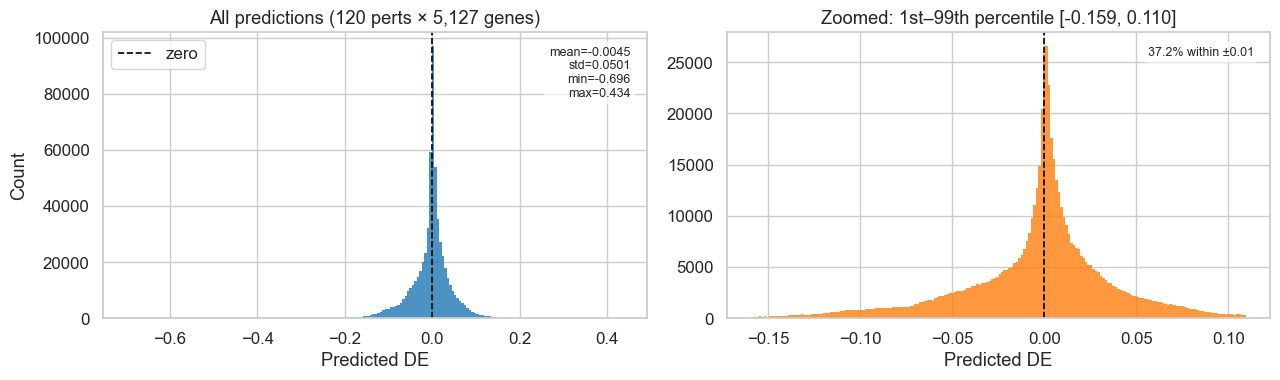

In [3]:
vals = sub.values.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full distribution
ax = axes[0]
ax.hist(vals, bins=200, color=PALETTE[0], alpha=0.8, edgecolor='none')
ax.axvline(0, color='black', lw=1.2, ls='--', label='zero')
ax.set_xlabel('Predicted DE')
ax.set_ylabel('Count')
ax.set_title('All predictions (120 perts × 5,127 genes)')
ax.legend()
stats_txt = (f'mean={vals.mean():.4f}\nstd={vals.std():.4f}\n'
             f'min={vals.min():.3f}\nmax={vals.max():.3f}')
ax.text(0.97, 0.95, stats_txt, transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# Right: zoomed to core (remove extreme tails for clarity)
ax = axes[1]
p1, p99 = np.percentile(vals, [1, 99])
core = vals[(vals >= p1) & (vals <= p99)]
ax.hist(core, bins=200, color=PALETTE[1], alpha=0.8, edgecolor='none')
ax.axvline(0, color='black', lw=1.2, ls='--')
ax.set_xlabel('Predicted DE')
ax.set_title(f'Zoomed: 1st–99th percentile [{p1:.3f}, {p99:.3f}]')
pct_near_zero = (np.abs(vals) < 0.01).mean() * 100
ax.text(0.97, 0.95, f'{pct_near_zero:.1f}% within ±0.01',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.tight_layout()
plt.savefig(FIG_DIR / '20_submission_de_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Clustermap — Perturbations × Genes

Clusters are on both axes. Use a gene subset for readability (top-variance genes).

/Users/luj12/Desktop/PROJECTS/Kaggle/Myllia_Perturb/.venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/luj12/Desktop/PROJECTS/Kaggle/Myllia_Perturb/.venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


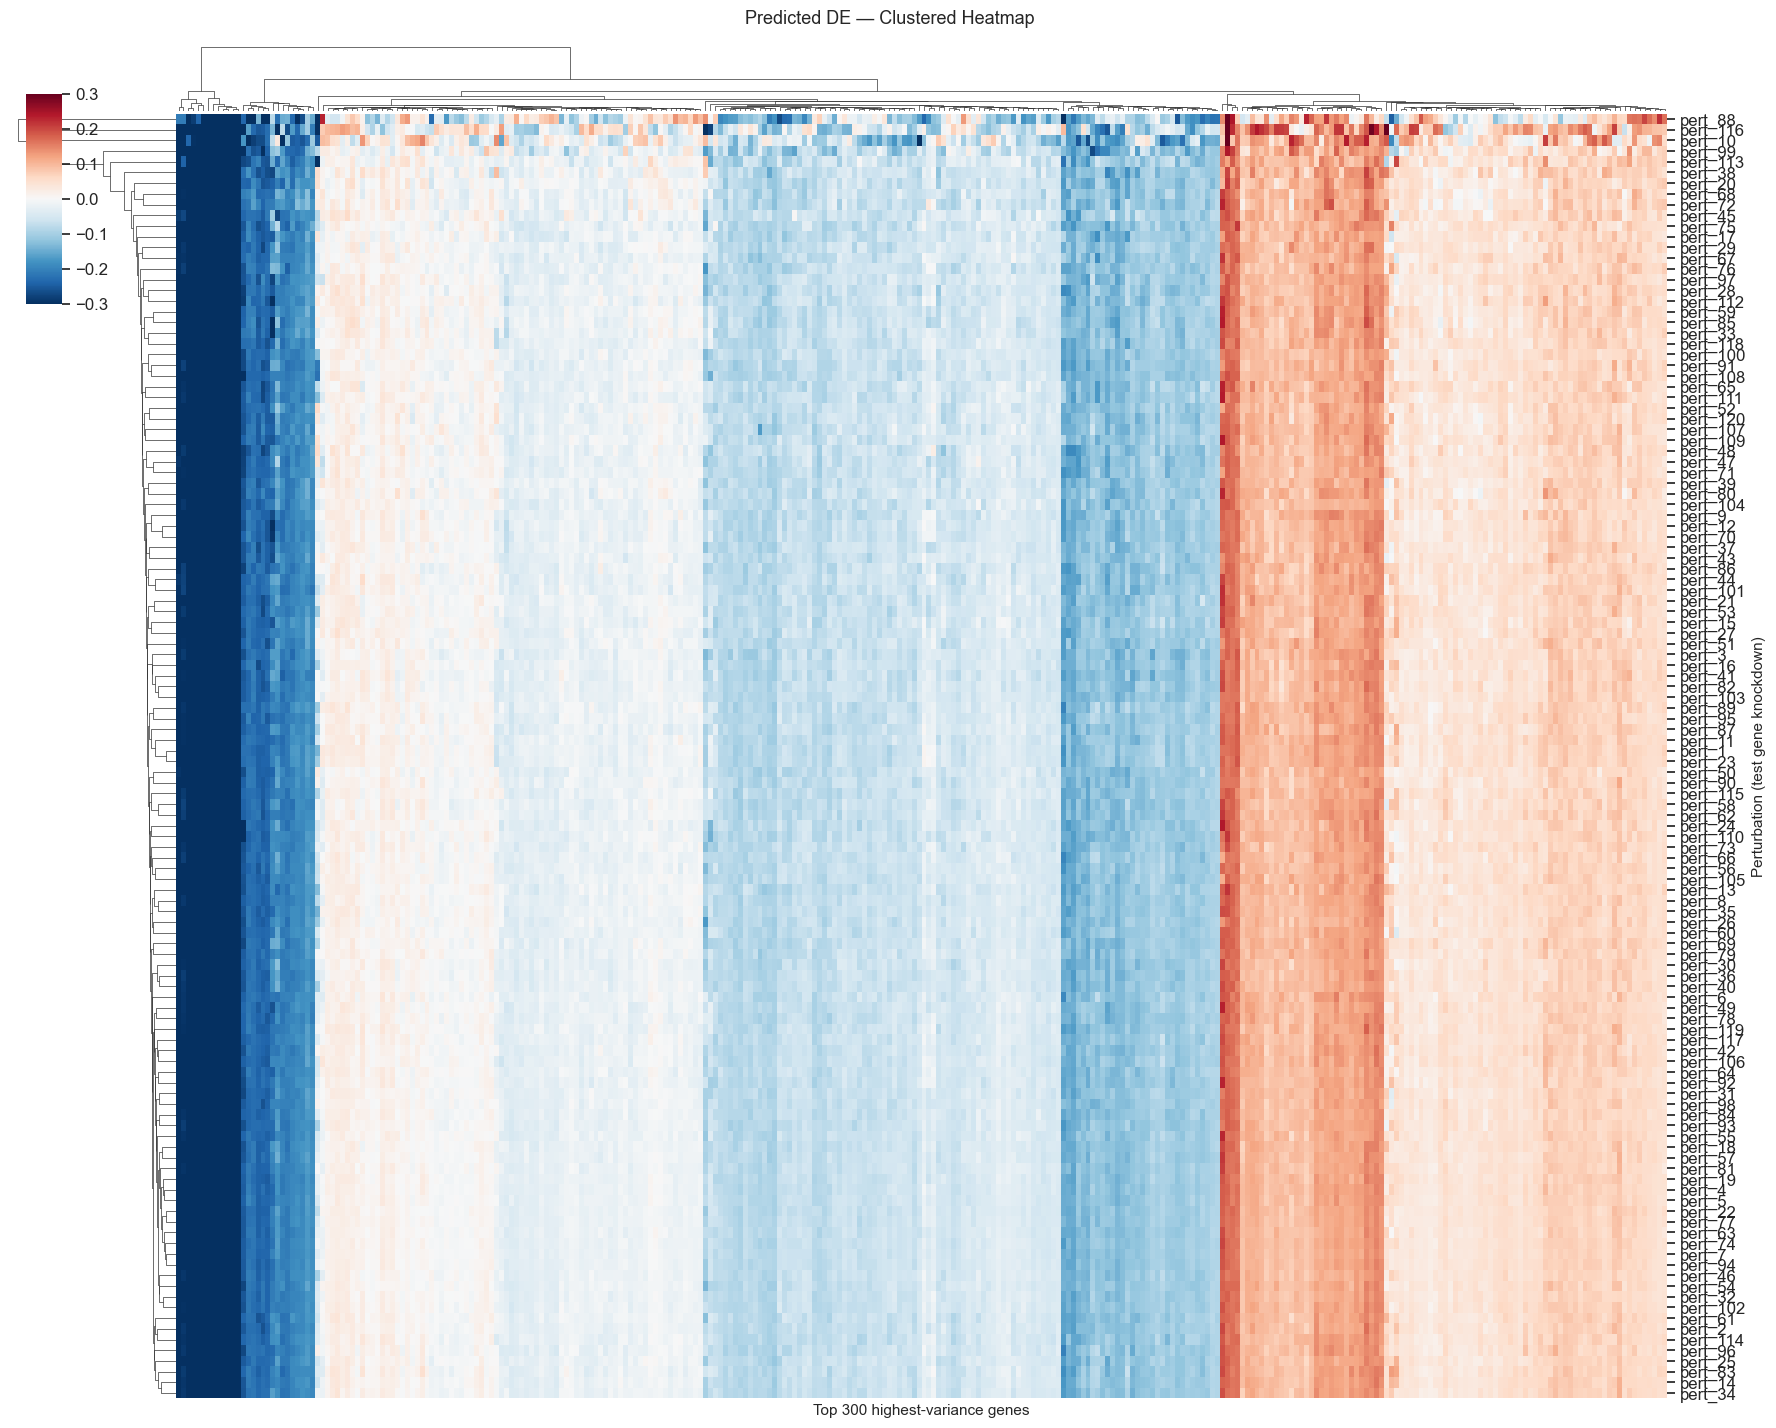

In [6]:
# Select top-N highest-variance genes across perturbations
N_GENES = 300
gene_var = sub.var(axis=0)
top_genes = gene_var.nlargest(N_GENES).index
sub_top = sub[top_genes]

# Row colors: val vs test split
if pert_split:
    split_colors = sub_top.index.map(lambda p: '#4C72B0' if pert_split.get(p, 'test') == 'val' else '#DD8452')
    row_colors = pd.Series(split_colors.values, index=sub_top.index, name='split')
else:
    row_colors = None

cg = sns.clustermap(
    sub_top,
    cmap='RdBu_r',
    center=0,
    vmin=-0.3, vmax=0.3,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(18, 14),
    dendrogram_ratio=(0.1, 0.05),
    cbar_pos=(0.02, 0.8, 0.02, 0.15),
)
cg.ax_heatmap.set_xlabel(f'Top {N_GENES} highest-variance genes', fontsize=11)
cg.ax_heatmap.set_ylabel('Perturbation (test gene knockdown)', fontsize=11)
cg.figure.suptitle('Predicted DE — Clustered Heatmap', y=1.01, fontsize=13)

if pert_split:
    from matplotlib.patches import Patch
    handles = [Patch(facecolor='#4C72B0', label='val'), Patch(facecolor='#DD8452', label='test')]
    cg.ax_row_colors.legend(handles=handles, title='Split',
                            bbox_to_anchor=(0, 1.02), loc='lower left', fontsize=9)

plt.savefig(FIG_DIR / '21_submission_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Perturbation Response Magnitude

Mean absolute DE per perturbation — a proxy for "how disruptive is this knockdown".

In [ ]:
mean_abs_de = sub.abs().mean(axis=1).sort_values(ascending=False)

colors = []
for p in mean_abs_de.index:
    s = pert_split.get(p, 'test')
    colors.append('#4C72B0' if s == 'val' else '#DD8452')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(mean_abs_de)), mean_abs_de.values, color=colors, width=0.8, edgecolor='none')

ax.set_xticks(range(len(mean_abs_de)))
ax.set_xticklabels(mean_abs_de.index, rotation=90, fontsize=7)
ax.set_ylabel('Mean |DE| across 5,127 genes')
ax.set_title('Response Magnitude per Perturbation (sorted)')
ax.axhline(mean_abs_de.mean(), color='black', lw=1.2, ls='--',
           label=f'mean = {mean_abs_de.mean():.4f}')

if pert_split:
    from matplotlib.patches import Patch
    handles = [Patch(facecolor='#4C72B0', label='val'), Patch(facecolor='#DD8452', label='test')]
    ax.legend(handles=handles + [plt.Line2D([0],[0], color='black', ls='--', label='mean')],
              fontsize=9)
else:
    ax.legend(fontsize=9)

# Annotate top-5
for i, (pert, val) in enumerate(mean_abs_de.head(5).items()):
    ax.annotate(pert, xy=(i, val), xytext=(i + 0.5, val + 0.001),
                fontsize=7, color='black', rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / '22_submission_response_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 highest-impact knockdowns:')
print(mean_abs_de.head(10).to_string())

## 4. Top Responding Genes per Perturbation

For a handful of example perturbations, show the 10 most up- and down-regulated predicted genes.

In [ ]:
# Pick examples: top-3 highest-magnitude + 1 low-magnitude perturbation
examples = list(mean_abs_de.head(3).index) + [mean_abs_de.index[len(mean_abs_de)//2]]
N_TOP = 10  # top N up + top N down

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, pert in zip(axes.ravel(), examples):
    row = sub.loc[pert].sort_values()
    # Top N down + top N up
    show = pd.concat([row.head(N_TOP), row.tail(N_TOP)])
    bar_colors = ['#d62728' if v > 0 else '#1f77b4' for v in show.values]
    
    ax.barh(range(len(show)), show.values, color=bar_colors, edgecolor='none')
    ax.set_yticks(range(len(show)))
    ax.set_yticklabels(show.index, fontsize=8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Predicted DE')
    mag = mean_abs_de[pert]
    ax.set_title(f'{pert}  (mean|DE|={mag:.4f})', fontsize=10)
    ax.invert_yaxis()

plt.suptitle(f'Top {N_TOP} Up/Down-regulated Genes per Perturbation', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '23_submission_top_genes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. UMAP of Predicted DE Vectors

Each point = one perturbation, embedded from 5,127D to 2D.  
Blue = training GT (if available), red/orange = test submission.

In [ ]:
from sklearn.preprocessing import StandardScaler
from umap import UMAP

# Stack training GT + test predictions for a joint embedding
if has_gt:
    combined  = pd.concat([train_de, sub_aligned], axis=0)
    labels    = (['train'] * len(train_de) + 
                 [pert_split.get(p, 'test') for p in sub_aligned.index])
else:
    combined  = sub_aligned
    labels    = [pert_split.get(p, 'test') for p in sub_aligned.index]

X = StandardScaler().fit_transform(combined.fillna(0).values)

reducer = UMAP(n_components=2, n_neighbors=10, min_dist=0.3, random_state=42, verbose=False)
emb = reducer.fit_transform(X)

emb_df = pd.DataFrame(emb, columns=['UMAP1', 'UMAP2'], index=combined.index)
emb_df['label'] = labels
print(emb_df['label'].value_counts())

In [ ]:
color_map = {'train': '#2ca02c', 'val': '#4C72B0', 'test': '#DD8452'}
size_map  = {'train': 60, 'val': 80, 'test': 80}
alpha_map = {'train': 0.5, 'val': 0.85, 'test': 0.85}
marker_map= {'train': 's', 'val': 'o', 'test': '^'}

fig, ax = plt.subplots(figsize=(9, 7))

for label, grp in emb_df.groupby('label'):
    ax.scatter(grp['UMAP1'], grp['UMAP2'],
               c=color_map.get(label, 'grey'),
               s=size_map.get(label, 60),
               alpha=alpha_map.get(label, 0.7),
               marker=marker_map.get(label, 'o'),
               edgecolors='white', linewidths=0.4,
               label=label, zorder=3 if label != 'train' else 2)

# Annotate a few extreme points (furthest from centroid)
centroid = emb_df[['UMAP1','UMAP2']].mean()
dist = np.linalg.norm(emb_df[['UMAP1','UMAP2']].values - centroid.values, axis=1)
emb_df['dist'] = dist
for _, row in emb_df[emb_df['label'] != 'train'].nlargest(5, 'dist').iterrows():
    ax.annotate(row.name, (row['UMAP1'], row['UMAP2']),
                xytext=(5, 3), textcoords='offset points', fontsize=7, alpha=0.9)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of DE Vectors — Train GT + Test Predictions')
ax.legend(title='Split', fontsize=9)
sns.despine()

plt.tight_layout()
plt.savefig(FIG_DIR / '24_submission_umap.png', dpi=150, bbox_inches='tight')
plt.show()

## Bonus: Per-Gene Prediction Variance

Which genes vary the most across the 120 predicted perturbations? These are genes whose expression is most context-dependent.

In [ ]:
gene_var_sorted = sub.var(axis=0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: top-30 genes by variance
ax = axes[0]
top30 = gene_var_sorted.head(30)
ax.barh(range(len(top30)), top30.values[::-1], color=PALETTE[2], edgecolor='none')
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index[::-1], fontsize=8)
ax.set_xlabel('Variance across 120 perturbations')
ax.set_title('Top 30 most variable genes')

# Right: variance distribution across all genes
ax = axes[1]
ax.hist(gene_var_sorted.values, bins=100, color=PALETTE[3], alpha=0.8, edgecolor='none')
ax.set_xlabel('Variance across perturbations')
ax.set_ylabel('Number of genes')
ax.set_title('Per-gene variance distribution')
p90 = np.percentile(gene_var_sorted.values, 90)
ax.axvline(p90, color='red', lw=1.2, ls='--', label=f'90th pct = {p90:.5f}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / '25_submission_gene_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most variable genes:')
print(gene_var_sorted.head(10).to_string())